
### 🌍 Análisis de Datos Demográficos aplicando los métodos estadísticos de correlación y regresión lineal

---

#### **1. 🎯 El Reto y Origen de los Datos**

En este proyecto, nuestro grupo se enfoca en la extracción y el análisis de datos demográficos globales utilizando la API pública RestCountries. Nos centraremos en las variables *Población* y *Área* para nuestros cálculos.

#### **2. 📊 Objetivo Estadístico**

Nuestra investigación consiste en determinar si existe una relación matemática predecible entre la extensión territorial de un país (Área) y el número de habitantes que alberga (Población).

Para ello, aplicaremos dos herramientas fundamentales de la estadística:

#### *1. Correlación de Pearson* 

#### *2. Regresión Lineal Simple* 

### **3. Justificación**

Comprender la correlación entre área y población es vital para el análisis de la *densidad demográfica*. 
Este estudio nos permitirá identificar **"outliers"** o casos atípicos: países con inmensos territorios pero baja población frente a naciones con superficies mínimas y altísima concentración humana.

## 🗝 Conceptos Clave

---

### 📈 Cálculo de la Correlación de Pearson (r): 

#### Mide la fuerza y dirección de una relación lineal entre dos variabl ¿a más territorio, siempre hay más gente?.

Para obtener r, la estadística contempla dos cosas: cómo varía cada variable por separado y cómo varían juntas. 

<center>
    <img src="imagenes/formula_r.png">
</center>

#### "Guía de interpretación de Pearson (r)"

 * **r = +1:** Relación positiva perfecta (línea recta ascendente).
 * **r = 0:** No existe relación lineal (puntos dispersos).
 * **r = -1:** Relación negativa perfecta (línea recta descendente).
 * **r < 0.3:** Correlación débil
 * **0.3 ≤ r < 0.7:** Correlación moderada
 * **r ≥ 0.7:** Correlación fuerte

<center>
    <img src="imagenes/correlacion_pearson.png" alt="Correlación Pearson" width="50%">
</center>




### 🗺 Consumo de la API y DataFrame

---

In [82]:
import requests
import pandas as pd
import numpy as np

url = "https://restcountries.com/v3.1/all?fields=name,capital,currencies,languages,region,population,area"
response = requests.get(url)
data = response.json()
rows = []
for country in data:
    rows.append({
        "country": country.get("name", {}).get("common"),
        "region": country.get("region", 'N/A'),
        "population": country.get("population", 0),
        "area": country.get("area"),
        })
df = pd.DataFrame(rows)

# Limpieza básica
df = df.dropna(subset=["population", "area"])
df = df[df["area"] > 0]
df["area"] = df["area"].astype(int)


# Variable derivada útil: densidad 
df["density"] = (df["population"] / df["area"]).round(2)

# Creamos una variable que genere una lista aleatoria de 30 países que usaremos como muestra para nuestros cálculos
df_muestra = df.sample(30, random_state=42).copy()

# Ordenamos la muestra por la columna 'region'

df_muestra_ordenada = df_muestra.sort_values(by="region")
print(f'Muestra  aleatoria de paises agrupados por región: ')

# Mostramos los 30 países (o los que tenga la muestra)

display(df_muestra_ordenada)

Muestra  aleatoria de paises agrupados por región: 


,country,region,population,area,density
67,South Africa,Africa,63100945,1221037,51.68
45,Ivory Coast,Africa,31719275,322463,98.37
19,Cape Verde,Africa,491233,4033,121.80
177,Gabon,Africa,2469296,267668,9.23
104,Mozambique,Africa,34090466,801590,42.53
9,Algeria,Africa,47400000,2381741,19.90
120,Gambia,Africa,2422712,10689,226.65
197,Ghana,Africa,33742380,238533,141.46
184,United States,Americas,340110988,9525067,35.71
200,Bahamas,Americas,398165,13943,28.56


In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar estilo
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("Estilo configurado! 🎨")


Estilo configurado! 🎨


#### CÁLCULO DE LA CORRELACION DE PEARSON (r)

---

In [84]:
import scipy
from scipy import stats  #(scipy.stats): Proporciona distribuciones de probabilidad, funciones de densidad y pruebas estadísticas para análisis de datos.

# Datos: poblacion vs area

poblacion = df_muestra["population"]
area = df_muestra["area"]

# Calcular correlación

r, p_value = stats.pearsonr(poblacion, area) # esta es la forma de calcular r y p_value con python

print(f'Los datos obtenidos para r y p_value son los siguientes: ')
print(f"Correlación de Pearson: {r:.2f}")
print(f"P-value: {p_value: .8f}")

if r == 1:
    print("➡️ Interpretación: Relación positiva perfecta (línea recta ascendente).")
elif r == -1:
    print("➡️ Interpretación: Relación negativa perfecta (línea recta descendente).")
elif r == 0:
    print("➡️ Interpretación: No existe relación lineal (puntos dispersos).")
elif r >= 0.7:
    print("➡️ Interpretación: Correlación FUERTE.")
elif r >= 0.3:
    print("➡️ Interpretación: Correlación MODERADA.")
else:
    print("➡️ Interpretación: Correlación DÉBIL.")




Los datos obtenidos para r y p_value son los siguientes: 
Correlación de Pearson: 0.83
P-value:  0.00000001
➡️ Interpretación: Correlación FUERTE.


Representación gráfica de la correlación entre la población de los distintos países estudiados en función del área: 


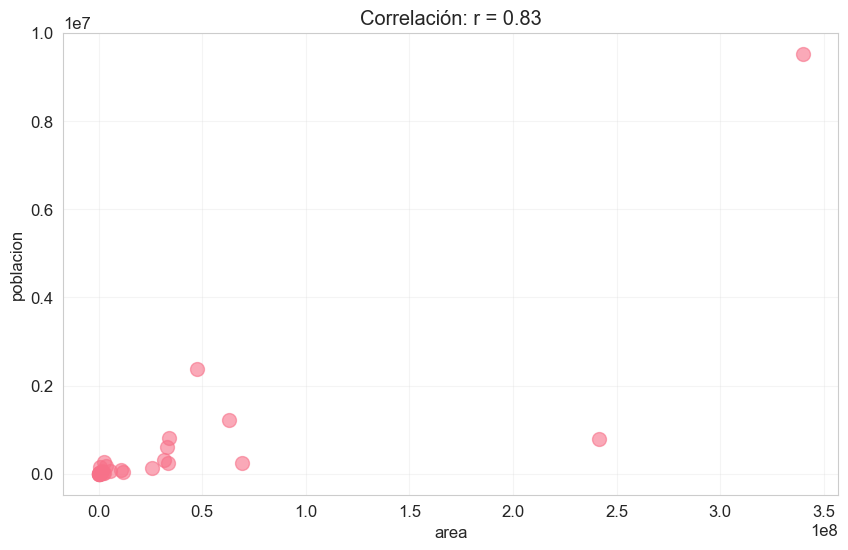

In [97]:
print(f'Representación gráfica de la correlación entre la población de los distintos países estudiados en función del área: ')

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(poblacion, area, s=100, alpha=0.6)
plt.xlabel('area')
plt.ylabel('poblacion')
plt.title(f'Correlación: r = {r:.2f}')
plt.grid(True, alpha=0.2)
plt.show()



#### Cálculo de la MATRIZ DE CORRELACIÓN:

---

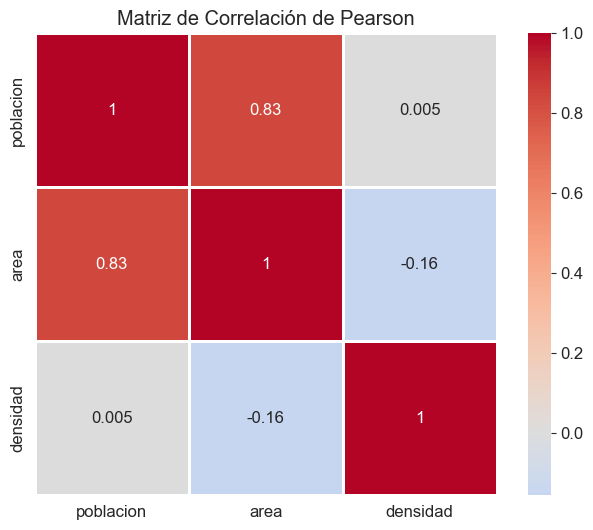

In [96]:
import pandas as pd
import seaborn as sns
df = pd.DataFrame({
    'poblacion': df_muestra_ordenada["population"],
    'area': df_muestra_ordenada["area"],
    'densidad': df_muestra_ordenada["density"]
    
})
# Calcular todas las correlaciones
corr_matrix = df.corr()

# Visualizacion

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1)
plt.title('Matriz de Correlación de Pearson')
plt.show()

#### CALCULO DEL COEFICIENTE DE SPEARMAN:

---

"Hemos decidido calcular Spearman además de Pearson porque los datos demográficos suelen presentar distribuciones asimétricas. Spearman,nos ofrece una visión más fiel de la tendencia global sin verse tan afectado por "outliers."

---


In [94]:
from scipy import stats

# 1. Calcular la matriz de correlación de Spearman usando Pandas
corr_spearman = df.corr(method='spearman')

# 2. Cálculo individual y condicional de interpretación (Ejemplo: Población vs Área)
rho, p_value = stats.spearmanr(df["poblacion"], df["area"])

print(f"Coeficiente de Spearman (rho): {rho:.4f}")
print(f"P-value: {p_value:.4f}")


Coeficiente de Spearman (rho): 0.9092
P-value: 0.0000


#### MATRIZ DE CORRELACIÓN DE SPEARMAN:
---

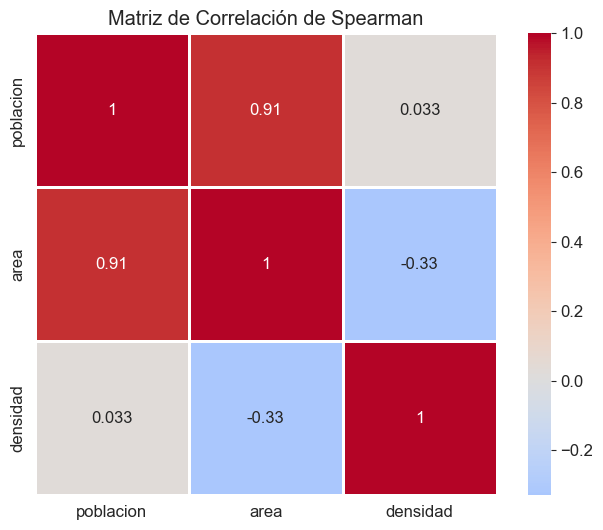

In [95]:
# 2. Visualizacion

plt.figure(figsize=(8, 6))
sns.heatmap(corr_spearman, annot=True, cmap='coolwarm', center=0, 
square=True, linewidths=1)
plt.title('Matriz de Correlación de Spearman')
plt.show()

#### REGRESION LINEAL:

---

La regresión lineal simple ayuda a hacer predicciones y a comprender las relaciones entre una variable independiente y una variable dependiente.

![alt text](imagenes/resumen-regresion-lineal.png)




In [103]:
# Regresión

from scipy.stats import linregress
slope, intercept, r_value, p_value, std_err = linregress(poblacion, area)

print(f"Pendiente (β₁): {slope:.2f}")
print(f"Intercepto (β₀): {intercept:.2f}")
print(f"R²: {r_value**2:.2f}")
print(f"P-value: {p_value:.4f}")

# Ecuación
print(f"\nEcuación: y = {intercept:.2f} + {slope:.2f}*x")

Pendiente (β₁): 0.02
Intercepto (β₀): -63651.06
R²: 0.69
P-value: 0.0000

Ecuación: y = -63651.06 + 0.02*x


❓ ¿qué significa cada dato obtenido?

---

**- La pendiente (0.02):** es la "velocidad" a la que crece la población según el tamaño del país. Por cada km2 adicional de superficie que tiene un país, se espera que su población aumente en 0.02 personas.

**- El intercepto:** es un indicador de que la relación no empieza exactamente en el origen (0,0).

**- R² (0.69):** Bondad de ajuste :Proporción de variabilidad en Y explicada por X. Indica que el 69% de la variación en la población de los países se explica únicamente por su área.

**- P-value:** Al ser menor a 0.05, significa que la relación es estadísticamente significativa.

---

📝 Conclusión:

Podemos afirmar con alto porcentaje de seguridad que el área influye en la población; los resultados no son fruto del azar. Es decir los países con un área mayor suelen ser los más poblados.

Y con la ecuación podríamos predecir la población esperada en un país en función del área, siendo x = area del país. 

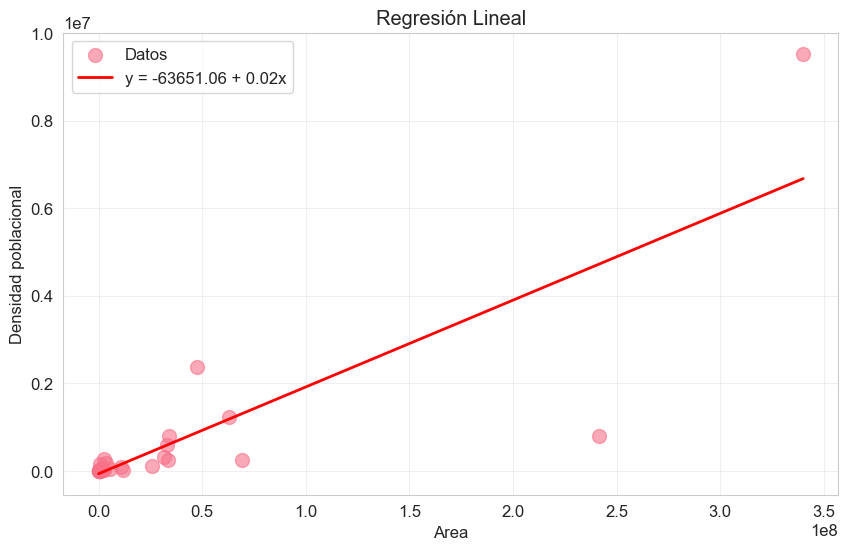

In [104]:
import numpy as np
import matplotlib.pyplot as plt

# Línea de regresión
x_line = np.linspace(min(poblacion), max(poblacion), 100)
y_line = intercept + slope * x_line

plt.figure(figsize=(10, 6))
plt.scatter(poblacion, area, s=100, alpha=0.6, label='Datos')
plt.plot(x_line, y_line, 'r-', linewidth=2, label=f'y = {intercept:.2f} + {slope:.2f}x')
plt.xlabel('Area')
plt.ylabel('Densidad poblacional')
plt.title('Regresión Lineal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### R²: BONDAD DE AJUSTE

---

**Interpretación:**
- **R² = 0.99:** El 99% de la variabilidad en cantidad se explica por el precio
- **R² = 0.50:** El 50% de la variabilidad se explica por el precio
- **R² = 0.10:** Mal ajuste, la relación lineal es débil

**¿Es bueno un R²?**
- **R² > 0.7:** Ajuste fuerte
- **0.4 < R² < 0.7:** Ajuste moderado
- **R² < 0.4:** Ajuste débil

#### RESIDUOS: ERRORES DEL MODELO

---

$$ \text{Residuo} = y_{real} - y_{predicho} $$



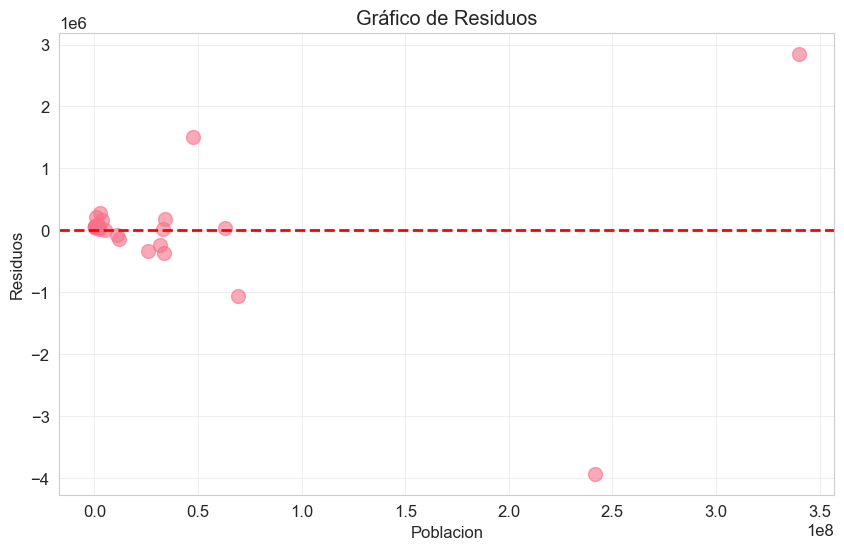

In [106]:
# Calcular predicciones
y_pred = intercept + slope * np.array(poblacion)

# Calcular residuos
residuos = np.array(area) - y_pred

# Visualizar
plt.figure(figsize=(10, 6))
plt.scatter(poblacion, residuos, s=100, alpha=0.6)
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Poblacion')
plt.ylabel('Residuos')
plt.title('Gráfico de Residuos')
plt.grid(True, alpha=0.3)
plt.show()

nuestro modelo no está funcionando bien para predecir la población de países grandes, se aleja mucho de la línea de puntos.

Celda 5 (Texto):

### 📊 Interpretación del Resultado: 

(INCORPORAREMOS LAS CONCLUSIONES DE NUESTRO ANALISIS)

"Al ejecutar el análisis, observamos ...................................................................................."

Celda 6 (Texto):

### ✂ 2 Errores Frecuentes

1. **Manejo de valores nulos (NaN)**: Algunos países pequeños no tienen informada el área o la población en la API. 

* Cómo evitarlo: Usar el método .get() con valores por defecto o limpiar el DataFrame con df.fillna(0).

2. **Exceso de peticiones (Rate Limiting)**: Hacer requests.get() dentro de un bucle for muy grande. 

* Cómo evitarlo: Hacer una sola petición masiva (como all) y filtrar los datos localmente en Python.

Celda 7 (Texto): 

### 🔗 Conexión con otro Grupo